In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('voice.csv')

df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [2]:
print(df.shape)
print(df.columns)
print(df['label'].value_counts())

#Memisahkan fitur dan target
X = df.drop('label', axis=1)
y = df['label']

(3168, 21)
Index(['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt',
       'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun',
       'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx', 'label'],
      dtype='str')
label
male      1584
female    1584
Name: count, dtype: int64


In [3]:
# Membagi dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=50,
    stratify=y
)

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

results = []

for feature in X.columns:

    X_train_feature = X_train[[feature]]
    X_test_feature = X_test[[feature]]

    scaler_feature = StandardScaler()

    X_train_scaled_feature = scaler_feature.fit_transform(X_train_feature)
    X_test_scaled_feature = scaler_feature.transform(X_test_feature)

    knn = KNeighborsClassifier(n_neighbors=5)

    knn.fit(X_train_scaled_feature, y_train)

    y_pred = knn.predict(X_test_scaled_feature)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        'Feature': feature,
        'Accuracy': accuracy
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print(results_df)

     Feature  Accuracy
12   meanfun  0.955836
5        IQR  0.903785
3        Q25  0.876972
1         sd  0.798107
8     sp.ent  0.731861
10      mode  0.668770
9        sfm  0.657729
17    maxdom  0.640379
11  centroid  0.624606
0   meanfreq  0.624606
2     median  0.602524
18   dfrange  0.602524
6       skew  0.597792
7       kurt  0.588328
15   meandom  0.574132
13    minfun  0.563091
16    mindom  0.556782
14    maxfun  0.534700
4        Q75  0.533123
19   modindx  0.507886


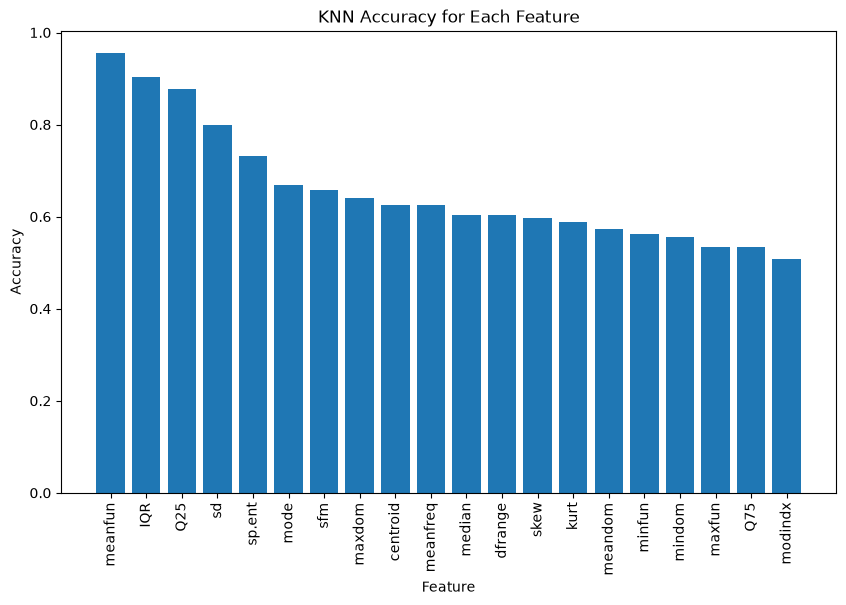

In [6]:
#2
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    results_df['Feature'],
    results_df['Accuracy']
)

plt.xlabel('Feature')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Each Feature')

plt.xticks(rotation=90)
plt.show()

2. Berdasarkan Percobaan, Meanfun merupakan fitur yang memberikan hasil klasifikasi terbaik karena menghasilkan nilai accuracy tertinggi dibandingkan fitur lainnya

In [7]:
# 3
best_feature = results_df.iloc[0]['Feature']
print("Best feature:", best_feature)

X_train_best = X_train[[best_feature]]
X_test_best = X_test[[best_feature]]

scaler_best = StandardScaler()

X_train_best = scaler_best.fit_transform(X_train_best)
X_test_best = scaler_best.transform(X_test_best)

Best feature: meanfun


In [8]:
# Mencoba berbagai nilai k untuk KNN
k_values = range(1, 21)

k_results = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_best, y_train)

    y_pred = knn.predict(X_test_best)

    accuracy = accuracy_score(y_test, y_pred)

    k_results.append({
        'k': k,
        'Accuracy': accuracy
    })

k_df = pd.DataFrame(k_results)

print(k_df)

     k  Accuracy
0    1  0.941640
1    2  0.938486
2    3  0.954259
3    4  0.951104
4    5  0.955836
5    6  0.954259
6    7  0.952681
7    8  0.951104
8    9  0.952681
9   10  0.954259
10  11  0.954259
11  12  0.957413
12  13  0.955836
13  14  0.954259
14  15  0.955836
15  16  0.951104
16  17  0.954259
17  18  0.952681
18  19  0.954259
19  20  0.954259


In [9]:
best_k = k_df.loc[
    k_df['Accuracy'].idxmax()
]

print("Best k:", best_k['k'])
print("Best accuracy:", best_k['Accuracy'])

Best k: 12.0
Best accuracy: 0.9574132492113565


nilai k dari 1 hingga 20, nilai k terbaik adalah 12, karena menghasilkan accuracy tertinggi sebesar 0.957413

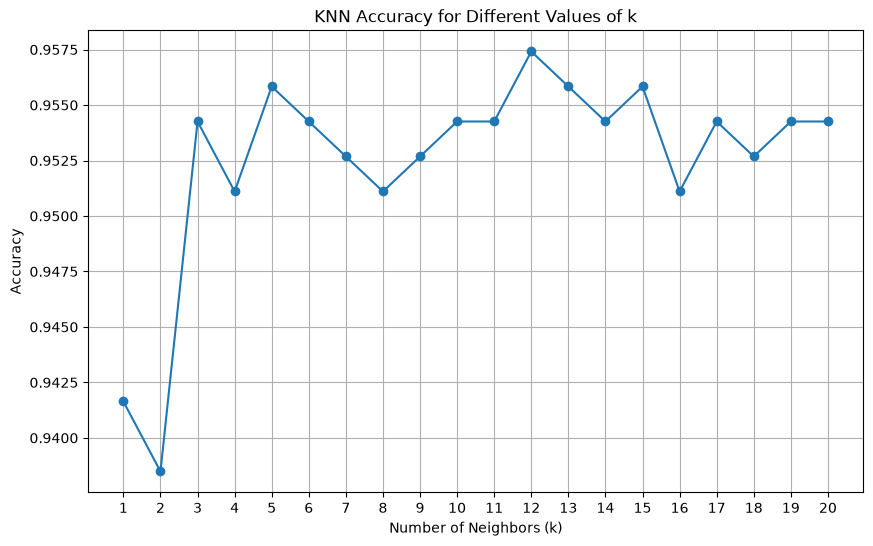

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_df['k'],
    k_df['Accuracy'],
    marker='o'
)

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different Values of k')

plt.xticks(k_values)
plt.grid(True)

plt.show()

#### 1. Model klasifikasi
Model klasifikasi dibangun menggunakan algoritma K-Nearest Neighbors (KNN) untuk mengklasifikasikan suara menjadi dua kelas, yaitu male dan female. Data dibagi menjadi data training dan testing, kemudian dilakukan standardisasi fitur karena KNN menggunakan perhitungan jarak dalam proses klasifikasi.

#### 2. Fitur Terbaik
engan menggunakan setiap fitur secara individual untuk mengetahui fitur yang memberikan performa klasifikasi terbaik. Setiap fitur diuji menggunakan KNN dengan k = 12. Fitur yang menghasilkan nilai accuracy tertinggi dipilih sebagai fitur optimal. Berdasarkan hasil percobaan, fitur Meanfun memberikan hasil terbaik 

#### 3. Nilai K terbaik
Setelah fitur terbaik diperoleh, dilakukan percobaan terhadap beberapa nilai k, yaitu 1 sampai 20. Hasil accuracy dari setiap nilai k dibandingkan untuk menentukan nilai yang memberikan performa terbaik.Berdasarkan hasil percobaan, nilai k = 12 memberikan accuracy tertinggi sebesar 0.9574132492113565. Oleh karena itu, nilai tersebut digunakan sebagai k terbaik pada model KNN.
